Initial Summarive Assesment

1.1 Clearly define the objective of the study. Your objective must explain the business problem, the analytical task, and what would count as a successful solution. You should identify measurable performance indicators and explain how these indicators relate to Mutuka Automotive’s need for reliable vehicle valuation and decision support. (5 Marks)

ans:

Answer

The overall Objective is to use the data within the car_pricing_datasets.csv in a creation of model that can close to acuratle predict the price of the vihcle based on the features.

siri:

 rows with na compered to whole 
 missing value per column 
 


1.2 Assess the integrity of the dataset and address any data-quality issues identified. Your analysis should consider missing values, duplicate records, inconsistent categories, incorrect data types, unrealistic or extreme values, and any other issues that may affect modelling. Clearly justify each data-handling decision and explain how poor data quality could affect the final valuation system.

 vehicle specification and pricing information, including attributes such as make or company name, fuel type, aspiration, body style, drive wheel, engine location, wheelbase, dimensions, curb weight, engine size, horsepower, city and highway fuel consumption, and price.
(8 Marks)

In [1]:
from ast import Lambda
import pandas as pd


cars = pd.read_csv("car_pricing_datasets.csv")
#consider missing values
clean_df = cars.dropna()

#duplicate records
Og_cars = clean_df.drop_duplicates()

# Done cleaning
print(Og_cars)

#inconsistent categories

#incorrect data types
#Og_cars = Og_cars.apply(pd.to_numeric, errors='coerce')
#unrealistic or extreme values
#print(cars.head())

#print(clean_df)
#print(clean_df.duplicated())

unique_array = Og_cars['CarName'].unique()
print(unique_array, "amount =",len(unique_array))

#print(datatype(Og_cars['CarName']))

     car_ID  symboling                   CarName fueltype aspiration  \
0       1.0        3.0        alfa-romero giulia      gas        std   
1       2.0        3.0       alfa-romero stelvio      gas        std   
2       3.0        1.0  alfa-romero Quadrifoglio      gas        std   
3       4.0        2.0               audi 100 ls      gas        std   
4       5.0        2.0                audi 100ls      gas        std   
..      ...        ...                       ...      ...        ...   
199   200.0       -1.0              volvo diesel      gas      turbo   
200   201.0       -1.0           volvo 145e (sw)      gas        std   
201   202.0       -1.0               volvo 144ea      gas      turbo   
203   204.0       -1.0                 volvo 246   diesel      turbo   
204   205.0       -1.0               volvo 264gl      gas      turbo   

    doornumber      carbody drivewheel enginelocation  wheelbase  ...  \
0          two  convertible        rwd          front       88

In [2]:
print(Og_cars.dtypes)

Og_cars['CarName'] = Og_cars['CarName'].astype('category')

print(Og_cars.dtypes)

car_ID              float64
symboling           float64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight          float64
enginetype           object
cylindernumber       object
enginesize          float64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower          float64
peakrpm             float64
citympg             float64
highwaympg          float64
price               float64
dtype: object
car_ID               float64
symboling            float64
CarName             category
fueltype              object
aspiration            object
doornumber            object
carbody               object
drivewheel            object
enginelocation        obje

In [3]:
# Convert Category to a dedicated 'category' type (memory efficient for few unique strings)
df_types['Category'] = df_types['Category'].astype('category')

NameError: name 'df_types' is not defined

In [4]:
# modifying
'''
unique_array = Og_cars['CarName'].unique()
print(unique_array, "amount =",len(unique_array))

'''
#Og_cars['CarName'] = Og_cars['CarName'].astype(float)

def string_to_integer(keys: str = str()):
    unique_array = Og_cars[keys].unique()
    name = {}

    for i in range (len(unique_array)):
    
        name[str(unique_array[i])] = int(i+1)
        #print(name)
    

    bool_map = name
    Og_cars[keys] = Og_cars[keys].map(bool_map)

    
    print(Og_cars.tail())
    Og_cars.to_csv('filename.csv', index=False)

string_to_integer('CarName')
string_to_integer('fueltype')
string_to_integer('aspiration') 
string_to_integer('doornumber') 
string_to_integer('carbody') 
string_to_integer('drivewheel') 
string_to_integer('enginelocation')
string_to_integer('enginetype')
string_to_integer('cylindernumber') 
string_to_integer('fuelsystem')

'''
bool_map = {'alfa-romero giulia': 1}
Og_cars['CarName'] = Og_cars['CarName'].map(bool_map)
print(Og_cars)
# Map text values directly to Python Booleans

'''
'''
bool_map = {'Yes': True, 'No': False, '1': True, '0': False, 'True': True, 'False': False}
df['your_column_name'] = df['your_column_name'].map(bool_map)
'''

     car_ID  symboling CarName fueltype aspiration doornumber carbody  \
199   200.0       -1.0     126      gas      turbo       four   wagon   
200   201.0       -1.0     121      gas        std       four   sedan   
201   202.0       -1.0     122      gas      turbo       four   sedan   
203   204.0       -1.0     127   diesel      turbo       four   sedan   
204   205.0       -1.0     125      gas      turbo       four   sedan   

    drivewheel enginelocation  wheelbase  ...  enginesize  fuelsystem  \
199        rwd          front      104.3  ...       130.0        mpfi   
200        rwd          front      109.1  ...       141.0        mpfi   
201        rwd          front      109.1  ...       141.0        mpfi   
203        rwd          front      109.1  ...       145.0         idi   
204        rwd          front      109.1  ...       141.0        mpfi   

     boreratio  stroke compressionratio horsepower  peakrpm citympg  \
199       3.62    3.15              7.5      162.0 

"\nbool_map = {'Yes': True, 'No': False, '1': True, '0': False, 'True': True, 'False': False}\ndf['your_column_name'] = df['your_column_name'].map(bool_map)\n"

1.3 Use appropriate visualisations and summary statistics to explore the relevant attributes. Your EDA should examine distributions, relationships between variables, potential predictors of price or valuation category, and any patterns that may influence model choice. You must interpret the results rather than simply displaying graphs.

(12 Marks)

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1. Prepare the dataset
# -----------------------------
y = Og_cars["price"]
X = Og_cars.drop(columns=["price"])

# -----------------------------
# 2. Create and train the model
# -----------------------------
model = LinearRegression()
model.fit(X, y)

# -----------------------------
# 3. Make predictions
# -----------------------------
y_pred = model.predict(X)

# -----------------------------
# 4. Evaluate the model
# -----------------------------
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Slope (coefficients):", model.coef_)
print("Intercept:", model.intercept_)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

# -----------------------------
# 5. Visualize (ONLY if 1 feature)
# -----------------------------

#plt.scatter(X, y, color='blue', label='Actual Data')
#plt.plot(X, y_pred, color='red', label='Regression Line')
#plt.xlabel("X")
#plt.ylabel("Price")
#plt.title("Linear Regression")
#plt.legend()
#plt.show()
print(X)
print("======================================================================================")
print(y)


Slope (coefficients): [ 1.09025626e+03  5.09631269e+03 -2.24705779e+03 -2.56157487e+04
  5.76130497e+04  1.22797083e+04 -5.16659003e+03 -1.96548116e+04
  3.40666381e+05  3.28564576e+03 -9.67903147e+02  8.57663514e+03
  3.51844668e+03  6.22744939e+01 -1.04015756e+04  3.32041771e+04
  1.54333723e+03 -5.04305226e+03  1.88800692e+04 -4.86379541e+04
  3.06298965e+03 -1.37659369e+02  1.75768824e+01 -2.77160510e+03
  3.62614658e+03]
Intercept: -1380468.6909003397
Mean Squared Error: 1803995968.8102298
R² Score: 0.9287393295228302
     car_ID  symboling  CarName  fueltype  aspiration  doornumber  carbody  \
0       1.0        3.0        1         1           1           1        1   
1       2.0        3.0        2         1           1           1        1   
2       3.0        1.0        3         1           1           1        2   
3       4.0        2.0        4         1           1           2        3   
4       5.0        2.0        5         1           1           2        3   
.. 

In [16]:
import pandas as pd

# Create a sample dataset
data = {
    'Name': ['John', 'Anna', 'John', 'Anna', 'John'],
    'Age': [28, 24, 28, 24, 19]
}
df = pd.DataFrame(data)

# Check for duplicates across the entire row
print(df.drop_duplicates())

   Name  Age
0  John   28
1  Anna   24
4  John   19


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# -----------------------------
# 1. Prepare the dataset
# -----------------------------
y = Og_cars["price"]
X = Og_cars.drop(columns=["price"])

# Handle non-numeric data by encoding categorical variables
X_processed = X.copy()
label_encoders = {}

for column in X_processed.columns:
    if X_processed[column].dtype == 'object':  # Check if column contains strings
        # Create a label encoder for this column
        label_encoders[column] = LabelEncoder()
        # Convert strings to numbers
        X_processed[column] = label_encoders[column].fit_transform(X_processed[column].astype(str))

# Convert all columns to numeric, handling any remaining non-numeric values
X_processed = X_processed.apply(pd.to_numeric, errors='coerce')

# Handle any NaN values that might have been created
X_processed = X_processed.fillna(0)

# -----------------------------
# 2. Create and train the model
# -----------------------------
model = LinearRegression()
model.fit(X_processed, y)

# -----------------------------
# 3. Make predictions
# -----------------------------
y_pred = model.predict(X_processed)

# -----------------------------
# 4. Evaluate the model
# -----------------------------
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Slope (coefficients):", model.coef_)
print("Intercept:", model.intercept_)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

# -----------------------------
# 5. Visualize (ONLY if 1 feature)
# -----------------------------
if X_processed.shape[1] == 1:
    plt.scatter(X_processed, y, color='blue', label='Actual Data')
    plt.plot(X_processed, y_pred, color='red', label='Regression Line')
    plt.xlabel("X")
    plt.ylabel("Price")
    plt.title("Linear Regression")
    plt.legend()
    plt.show()
else:
    print("Visualization skipped (multiple features detected)")

Slope (coefficients): [ 1.09025626e+03  5.09631269e+03 -2.24705779e+03 -2.56157487e+04
  5.76130497e+04  1.22797083e+04 -5.16659003e+03 -1.96548116e+04
  3.40666381e+05  3.28564576e+03 -9.67903147e+02  8.57663514e+03
  3.51844668e+03  6.22744939e+01 -1.04015756e+04  3.32041771e+04
  1.54333723e+03 -5.04305226e+03  1.88800692e+04 -4.86379541e+04
  3.06298965e+03 -1.37659369e+02  1.75768824e+01 -2.77160510e+03
  3.62614658e+03]
Intercept: -1380468.6909003397
Mean Squared Error: 1803995968.8102298
R² Score: 0.9287393295228302
Visualization skipped (multiple features detected)


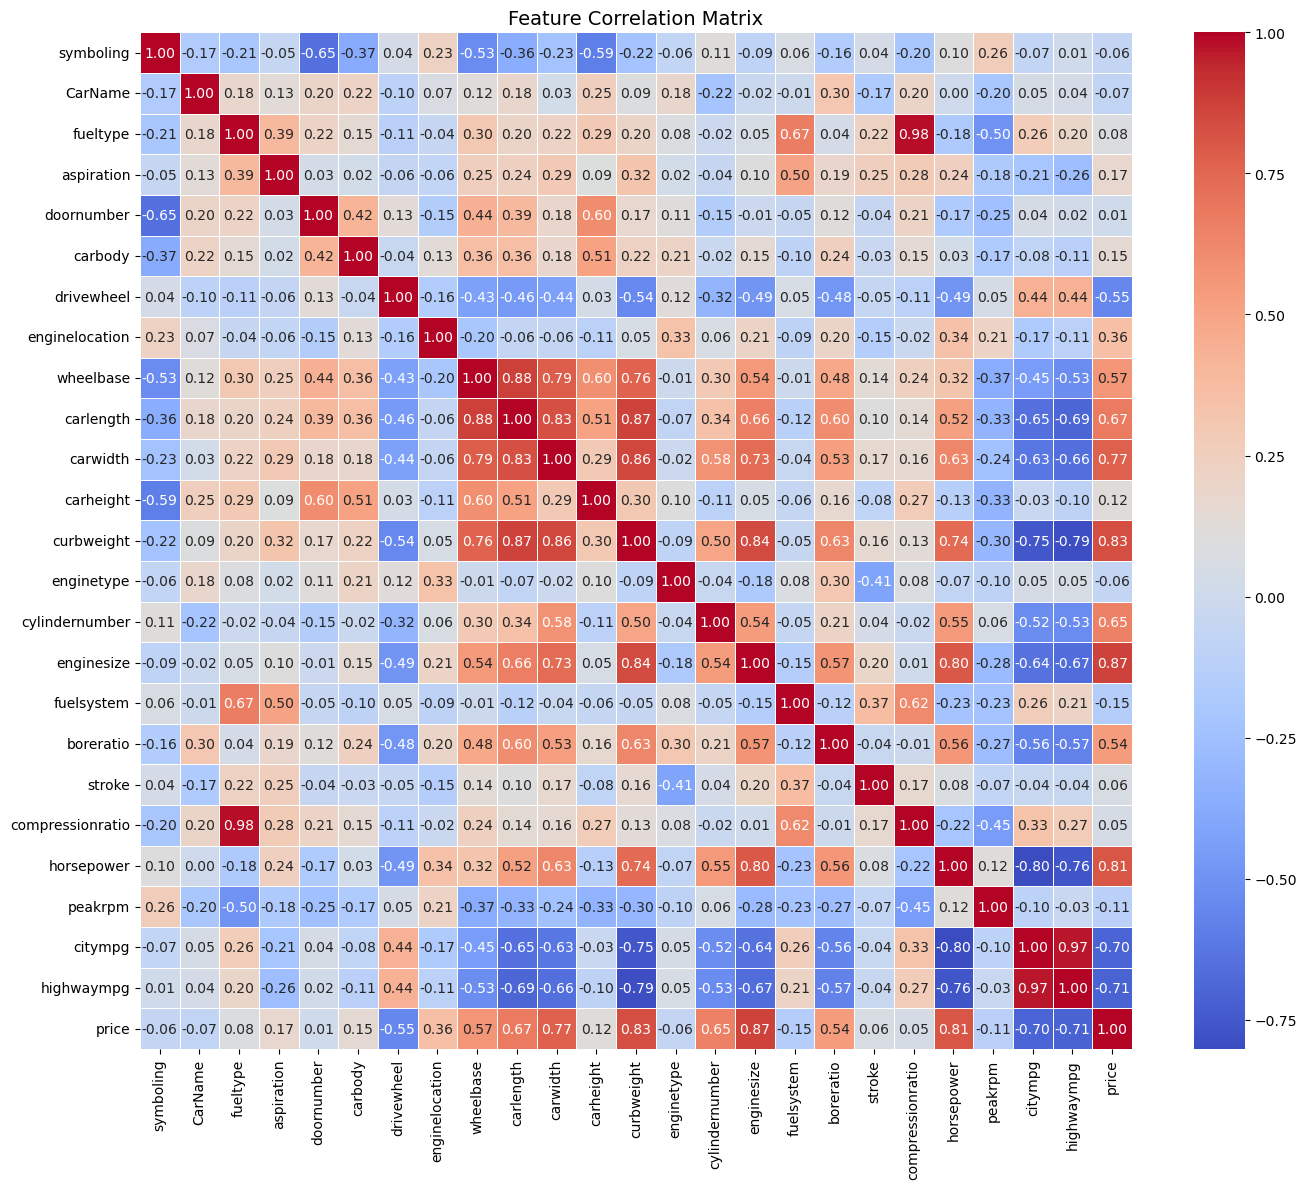

In [8]:
import seaborn as sns # Used for clean heatmap layout over matplotlib

# Calculate correlation matrix
corr = Og_cars.drop(columns=["car_ID"]).corr()

plt.figure(figsize=(14, 12))
# annot=True shows numbers; for >20 features, set to False to avoid clutter
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5) 
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

enginesize, curbweight and horsepower have the highest impact to price.
The least is door highwaympg, citympg,  and drivewheel

pythonanywhere 

In [9]:
x = 4 + X
y = 4 + y
# size and color:
sizes = np.random.uniform(15, 80, len(x))
colors = np.random.uniform(15, 80, len(x))
fig, ax = plt.subplots()

ax.scatter(x, y, s=sizes, c= colors, vmin=0, vmax=100)

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8))

plt.show()

TypeError: unsupported operand type(s) for +: 'int' and 'Categorical'

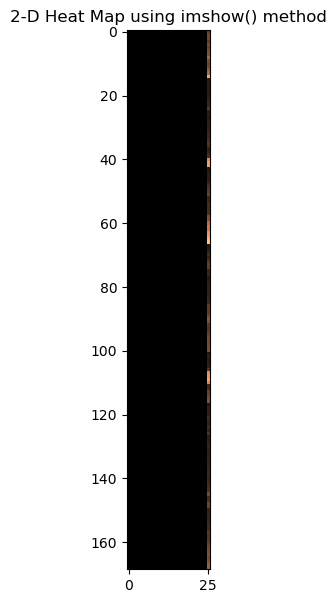

In [10]:
#2-D Heat map using matplotlib.pyplot.imshow() method
import numpy as np
import matplotlib.pyplot as plt


fig = plt.figure(figsize = (7, 7)) 
plt.imshow( Og_cars, cmap = 'copper' , interpolation = 'nearest' )
plt.title( "2-D Heat Map using imshow() method" )
plt.show()
